In [9]:
# from dotenv import load_dotenv
# import os
# load_dotenv()
# KAGGLE_USER = os.getenv("KAGGLE_USERNAME")
# KAGGLE_API_TOKEN = os.getenv("KAGGLE_API_TOKEN")
# path = kagglehub.dataset_download("nih-chest-xrays/data")

In [21]:
import os
import copy
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms

import os
import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image


# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [22]:
def scan_available_files(image_folders):
    """
    Returns a set of all filenames available under the provided image_folders.
    Assumes each folder has an 'images' subfolder (as in your dataset).
    """
    available = set()
    for folder in image_folders:
        if not os.path.isdir(folder):
            raise ValueError(f"[scan_available_files] Not a directory: {folder}")

        for fn in os.listdir(folder):
            if fn.lower().endswith((".png", ".jpg", ".jpeg")):
                available.add(fn)
    return available


def build_patient_splits_minimal(
    csv_path,
    filename_col="Image Index",
    patient_col="Patient ID",
    train_folders=None,
    val_folders=None,
    test_folders=None,
):
    assert train_folders and val_folders and test_folders, "Need folder lists for all splits."

    # 1) Load once
    df = pd.read_csv(csv_path)

    # 2) Clean filename column (helps avoid silent mismatches)
    df[filename_col] = df[filename_col].astype(str).str.strip()

    # 3) Keep only FIRST row per patient globally (prevents patient leakage logic issues)
    df = df.drop_duplicates(subset=patient_col, keep="first").reset_index(drop=True)

    # 4) Scan files actually present in each split
    train_files = scan_available_files(train_folders)
    val_files   = scan_available_files(val_folders)
    test_files  = scan_available_files(test_folders)

    # 5) Filter rows by file existence in each split
    df_train = df[df[filename_col].isin(train_files)].copy()
    df_val   = df[df[filename_col].isin(val_files)].copy()
    df_test  = df[df[filename_col].isin(test_files)].copy()

    # 6) Remove patient overlaps deterministically (train > val > test)
    train_pids = set(df_train[patient_col].unique())
    df_val  = df_val[~df_val[patient_col].isin(train_pids)]
    val_pids = set(df_val[patient_col].unique())
    df_test = df_test[~df_test[patient_col].isin(train_pids | val_pids)]

    # 7) Sanity prints
    train_pids = set(df_train[patient_col].unique())
    val_pids   = set(df_val[patient_col].unique())
    test_pids  = set(df_test[patient_col].unique())

    print("[Split rows] train/val/test:", len(df_train), len(df_val), len(df_test))
    print("[Split patients] train/val/test:", len(train_pids), len(val_pids), len(test_pids))
    print("[Overlaps] train∩val:", len(train_pids & val_pids),
          "train∩test:", len(train_pids & test_pids),
          "val∩test:", len(val_pids & test_pids))

    return df_train.reset_index(drop=True), df_val.reset_index(drop=True), df_test.reset_index(drop=True)

In [23]:
import numpy as np

def add_binary_label_column(df, finding_col="Finding Labels", out_col="binary_label"):
    """
    Adds a column with values: 'Healthy' if Finding Labels == 'No Finding' else 'Diseased'
    """
    df = df.copy()
    raw = df[finding_col].astype(str).str.strip()
    df[out_col] = np.where(raw == "No Finding", "Healthy", "Diseased")
    return df


def balance_50_50(df, label_col="binary_label", seed=42, method="undersample"):
    """
    Enforce 50/50 class balance between Healthy and Diseased.

    method:
      - 'undersample': downsample majority class to match minority (no duplicates)
      - 'oversample' : upsample minority class to match majority (adds duplicates)
    """
    rng = np.random.default_rng(seed)

    df = df.copy()
    counts = df[label_col].value_counts()
    if len(counts) < 2:
        raise ValueError(f"[balance_50_50] Need both classes present. Counts: {counts.to_dict()}")

    df_h = df[df[label_col] == "Healthy"]
    df_d = df[df[label_col] == "Diseased"]

    n_h = len(df_h)
    n_d = len(df_d)

    if method == "undersample":
        n = min(n_h, n_d)
        df_h_bal = df_h.sample(n=n, replace=False, random_state=seed)
        df_d_bal = df_d.sample(n=n, replace=False, random_state=seed)

    elif method == "oversample":
        n = max(n_h, n_d)
        df_h_bal = df_h.sample(n=n, replace=(n > n_h), random_state=seed)
        df_d_bal = df_d.sample(n=n, replace=(n > n_d), random_state=seed)

    else:
        raise ValueError("method must be 'undersample' or 'oversample'")

    df_bal = (
        np.random.permutation(pd.concat([df_h_bal, df_d_bal], axis=0).index)
    )
    # Shuffle rows
    out = pd.concat([df_h_bal, df_d_bal], axis=0).loc[df_bal].reset_index(drop=True)

    # sanity print
    print("[balance_50_50] after:", out[label_col].value_counts().to_dict())
    return out

In [24]:
class CSVDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        csv_path,
        image_folders,
        tfms=None,
        filename_col="Image Index",
        label_col="Finding Labels",
        df_override=None,
        verbose=False,
    ):
        # ---- Load dataframe ----
        if df_override is not None:
            self.df = df_override.copy()
        else:
            self.df = pd.read_csv(csv_path)

        # Clean filename col to avoid whitespace mismatches
        self.df[filename_col] = self.df[filename_col].astype(str).str.strip()

        self.transform = tfms
        self.filename_col = filename_col
        self.label_col = label_col

        # Normalize folder input
        if isinstance(image_folders, str):
            self.image_dirs = [image_folders]
        else:
            self.image_dirs = list(image_folders)

        # Build filename -> full path map
        self.path_map = {}
        total_files_found = 0

        for d in self.image_dirs:
            if not os.path.isdir(d):
                raise ValueError(f"[CSVDataset] Image directory not found: {d}")

            for f in os.listdir(d):
                if not f.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue

                full = os.path.join(d, f)
                if os.path.isfile(full):
                    total_files_found += 1
                    if f not in self.path_map:
                        self.path_map[f] = full

        available_files = set(self.path_map.keys())

        before = len(self.df)
        self.df = self.df[self.df[filename_col].isin(available_files)].reset_index(drop=True)
        after = len(self.df)

        if verbose:
            print(f"[CSVDataset] Loaded CSV rows: {before}")
            print(f"[CSVDataset] Image folders: {self.image_dirs}")
            print(f"[CSVDataset] Total image files scanned: {total_files_found}")
            print(f"[CSVDataset] Unique filenames available: {len(available_files)}")
            print(f"[CSVDataset] Kept rows with existing images: {after}")
            print(f"[CSVDataset] Dropped rows missing images: {before - after}")

        if len(self.df) == 0:
            raise ValueError(
                "[CSVDataset] Dataset is empty after filtering.\n"
                "Most likely causes:\n"
                " - wrong folder paths (must point to .../images)\n"
                " - filename_col mismatch (expected 'Image Index')\n"
                " - filenames in CSV don't match actual files (whitespace/extension)\n"
            )

        # Label mapping
        self.label_to_idx = None
        if self.label_col is not None:
            if self.label_col == "Finding Labels":
                self.label_to_idx = {"Healthy": 0, "Diseased": 1}
            else:
                labels = sorted(self.df[self.label_col].unique())
                self.label_to_idx = {lab: i for i, lab in enumerate(labels)}

            if verbose:
                print(f"[CSVDataset] label_to_idx: {self.label_to_idx}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row[self.filename_col]

        path = self.path_map.get(filename)
        if path is None:
            raise FileNotFoundError(f"[CSVDataset] Missing file at runtime: {filename}")

        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        if self.label_col is None:
            return img

        if self.label_col == "Finding Labels":
            raw = str(row[self.label_col]).strip()
            label_str = "Healthy" if raw == "No Finding" else "Diseased"
            y = self.label_to_idx[label_str]
            return img, torch.tensor(y, dtype=torch.long)

        y = self.label_to_idx[row[self.label_col]]
        return img, torch.tensor(y, dtype=torch.long)

In [30]:
train_folders = ["./Datasets/archive/images_001/images",
                 "./Datasets/archive/images_002/images",
                 "./Datasets/archive/images_003/images",
                 "./Datasets/archive/images_004/images",
                 "./Datasets/archive/images_005/images",
                 "./Datasets/archive/images_006/images",
                 "./Datasets/archive/images_007/images"]
val_folders   = ["./Datasets/archive/images_008/images"]
test_folders  = ["./Datasets/archive/images_009/images"]
csv_path = "./Datasets/archive/Data_Entry_2017.csv"

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

eval_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_df, val_df, test_df = build_patient_splits_minimal(
    csv_path=csv_path,
    filename_col="Image Index",
    patient_col="Patient ID",
    train_folders=train_folders,
    val_folders=val_folders,
    test_folders=test_folders,
)

# Add binary label to each split (for balancing + quick sanity checks)
train_df = add_binary_label_column(train_df, finding_col="Finding Labels", out_col="binary_label")
val_df   = add_binary_label_column(val_df,   finding_col="Finding Labels", out_col="binary_label")
test_df  = add_binary_label_column(test_df,  finding_col="Finding Labels", out_col="binary_label")

print("Before balancing train:", train_df["binary_label"].value_counts().to_dict())

# Balance TRAIN to 50/50
# Choose ONE:
train_df = balance_50_50(train_df, label_col="binary_label", seed=42, method="undersample")
# train_df = balance_50_50(train_df, label_col="binary_label", seed=42, method="oversample")

train_ds = CSVDataset(csv_path, train_folders, tfms=train_tfms, df_override=train_df, verbose=True)
val_ds   = CSVDataset(csv_path, val_folders,   tfms=eval_tfms,  df_override=val_df,  verbose=True)
test_ds  = CSVDataset(csv_path, test_folders,  tfms=eval_tfms,  df_override=test_df, verbose=True)

[Split rows] train/val/test: 16051 2336 2558
[Split patients] train/val/test: 16051 2336 2558
[Overlaps] train∩val: 0 train∩test: 0 val∩test: 0
Before balancing train: {'Healthy': 11383, 'Diseased': 4668}
[balance_50_50] after: {'Diseased': 4668, 'Healthy': 4668}
[CSVDataset] Loaded CSV rows: 9336
[CSVDataset] Image folders: ['./Datasets/archive/images_001/images', './Datasets/archive/images_002/images', './Datasets/archive/images_003/images', './Datasets/archive/images_004/images', './Datasets/archive/images_005/images', './Datasets/archive/images_006/images', './Datasets/archive/images_007/images']
[CSVDataset] Total image files scanned: 64999
[CSVDataset] Unique filenames available: 64999
[CSVDataset] Kept rows with existing images: 9336
[CSVDataset] Dropped rows missing images: 0
[CSVDataset] label_to_idx: {'Healthy': 0, 'Diseased': 1}
[CSVDataset] Loaded CSV rows: 2336
[CSVDataset] Image folders: ['./Datasets/archive/images_008/images']
[CSVDataset] Total image files scanned: 1000

In [32]:
pin = (device.type == "cuda")
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0, pin_memory=pin)

In [34]:
class SimpleCNN(nn.Module):
    """
    Simple CNN adapted for large images (e.g., 1024x1024):
    - Uses stride=2 convolutions (or pooling with stride=2) to downsample aggressively
    - Uses Global Average Pooling to avoid massive Flatten -> FC parameter explosion
    """
    def __init__(self, num_classes=10):
        super().__init__()

        # Downsample 1024 -> 512
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # (N,32,512,512)
            nn.ReLU(inplace=True),
        )

        # 512 -> 256
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # (N,64,256,256)
            nn.ReLU(inplace=True),
        )

        # 256 -> 128
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # (N,128,128,128)
            nn.ReLU(inplace=True),
        )

        # 128 -> 64
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1), # (N,256,64,64)
            nn.ReLU(inplace=True),
        )

        # Global Average Pooling: (N,256,64,64) -> (N,256,1,1)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Small classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),               # (N,256)
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

In [36]:
# Training configuration
NUM_EPOCHS = 15
LEARNING_RATE = 0.001

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
model = SimpleCNN(num_classes=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (reduce LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2#, verbose=True
)

In [38]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

In [40]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

In [42]:
EARLY_STOP_PATIENCE = 3
MIN_DELTA = 0.0

train_losses, train_accs = [], []
val_losses, val_accs     = [], []

best_val_acc = -float("inf")
best_epoch = -1
best_state = None
epochs_without_improve = 0

print("Starting training...")
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12}")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if val_acc > best_val_acc + MIN_DELTA:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    print(f"{epoch+1:<8} {train_loss:<12.4f} {train_acc:<12.2f} {val_loss:<12.4f} {val_acc:<12.2f}")

    if epochs_without_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping: val acc hasn't improved for {EARLY_STOP_PATIENCE} epoch(s).")
        break

print("\nTraining complete!")
print(f"Best Val Acc: {best_val_acc:.4f} at epoch {best_epoch}")

if best_state is not None:
    model.load_state_dict(best_state)

Starting training...
Epoch    Train Loss   Train Acc    Val Loss     Val Acc     
------------------------------------------------------------
1        0.6937       50.21        0.6982       33.52       
2        0.6932       50.85        0.6918       55.99       
3        0.6923       52.09        0.6909       50.43       
4        0.6911       53.16        0.7127       35.62       
5        0.6913       53.17        0.7041       37.84       

Early stopping: val acc hasn't improved for 3 epoch(s).

Training complete!
Best Val Acc: 55.9932 at epoch 2


In [43]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print("\nTest set results (best-val checkpoint):")
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}")


Test set results (best-val checkpoint):
Test Loss: 0.6925 | Test Acc: 53.44


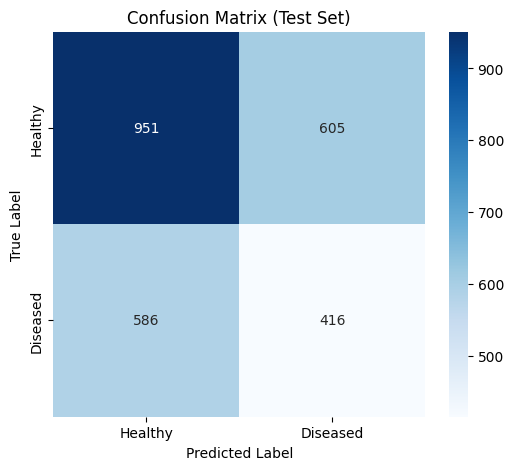

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure model is in evaluation mode
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy","Diseased"],
    yticklabels=["Healthy","Diseased"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Set)")
plt.show()

In [ ]:
# adding this to save weights and data
# run np.load(predictions.npy, alow_pickle=True).item() to load data

In [52]:
# Save model weights
torch.save(model.state_dict(), "JeremyCode.pth")

# Save training history
history = {
    "train_losses": train_losses,
    "train_accs":   train_accs,
    "val_losses":   val_losses,
    "val_accs":     val_accs,
    "best_val_acc": best_val_acc,
    "best_epoch":   best_epoch,
}
torch.save(history, "training_history_JeremyCode.pth")

In [54]:
def get_predictions(model, loader, device):
    model.eval()
    all_preds   = []
    all_labels  = []
    all_probs   = []  # useful for ROC curves, AUC etc.

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            probs  = torch.softmax(logits, dim=1)
            preds  = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    return (np.array(all_preds), 
            np.array(all_labels), 
            np.array(all_probs))

In [ ]:
train_preds, train_labels, train_probs = get_predictions(model, train_loader, device)
val_preds,   val_labels,   val_probs   = get_predictions(model, val_loader,   device)
test_preds,  test_labels,  test_probs  = get_predictions(model, test_loader,  device)

predictions = {
    "train": {"preds": train_preds, "labels": train_labels, "probs": train_probs},
    "val":   {"preds": val_preds,   "labels": val_labels,   "probs": val_probs},
    "test":  {"preds": test_preds,  "labels": test_labels,  "probs": test_probs},
}

np.save("predictions.npy", predictions)